In [27]:
import os
import kagglehub
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.utils.class_weight import compute_class_weight
from pathlib import Path
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import Sequential, layers, Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
from PIL import Image
import cv2


In [2]:
os.environ["KAGGLEHUB_CACHE"] = "data/kagglehub_cache"

path = kagglehub.dataset_download(
    "preetviradiya/brian-tumor-dataset"
)
print(path)

data/kagglehub_cache\datasets\preetviradiya\brian-tumor-dataset\versions\1


In [3]:
def load_images_from_folders(root_path):
    images = []
    labels = []

    class_map = {
        "Brain Tumor": 1,
        "Healthy": 0
    }

    for class_name, label in class_map.items():
        class_path = os.path.join(root_path, class_name)
        for file in os.listdir(class_path):
            if file.lower().endswith(('.jpg', '.jpeg', '.png', '.tif', '.tiff')):
                img_path = os.path.join(class_path, file)

                try:
                    img = Image.open(img_path)
                    img = img.convert("RGB")
                    img = img.resize((128, 128))
                    img_array = np.array(img)
                    if img_array.dtype == np.uint16:
                        img_array = img_array.astype(np.float32) / 65535.0
                    else:
                        img_array = img_array.astype(np.float32) / 255.0

                    images.append(img_array)
                    labels.append(label)

                except Exception as e:
                    print(f"Ошибка: {file} -> {e}")

    return np.array(images), np.array(labels)

In [4]:
root_path = Path(path) / "Brain Tumor Data Set" / "Brain Tumor Data Set"
X, Y = load_images_from_folders(
    root_path=root_path
)

print(X.shape)
print(Y.shape)

sss = StratifiedShuffleSplit(n_splits=1, train_size=0.8, random_state=42)
train_idx, test_idx = next(sss.split(X, Y))

x_train, x_test = X[train_idx], X[test_idx]
y_train, y_test = Y[train_idx].astype(np.float32), Y[test_idx].astype(np.float32)

(4600, 128, 128, 3)
(4600,)


In [5]:
def check_class_balance(labels, name):
    unique, counts = np.unique(labels, return_counts=True)

    print(f"\n{name} распределение:")
    for u, c in zip(unique, counts):
        class_name = "Healhty (0)" if u == 0 else "Brain Tumor (1)"
        percent = (c / len(labels)) * 100
        print(f"{class_name}: {c} изображений ({percent:.2f}%)")

check_class_balance(y_train, "Train выборка")
check_class_balance(y_test, "Test выборка")


Train выборка распределение:
Healhty (0): 1670 изображений (45.38%)
Brain Tumor (1): 2010 изображений (54.62%)

Test выборка распределение:
Healhty (0): 417 изображений (45.33%)
Brain Tumor (1): 503 изображений (54.67%)


In [6]:
# описание модели
model_max = Sequential([
    Input(shape=(128,128,3)),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

In [7]:
class_weights = compute_class_weight('balanced',
                                     classes=np.unique(y_train),
                                     y=y_train)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

# сборка модели
model_max.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

# # # обучение модели
model_max.fit(x_train, y_train, batch_size=16,
              epochs=5,
              validation_data=(x_test, y_test),
              class_weight=class_weight_dict)

Epoch 1/5
230/230 ━━━━━━━━━━━━━━━━━━━━ 35s 137ms/step - accuracy: 0.7361 - loss: 0.5443 - val_accuracy: 0.8413 - val_loss: 0.3828
Epoch 2/5
230/230 ━━━━━━━━━━━━━━━━━━━━ 29s 127ms/step - accuracy: 0.8489 - loss: 0.3524 - val_accuracy: 0.8891 - val_loss: 0.2806
Epoch 3/5
230/230 ━━━━━━━━━━━━━━━━━━━━ 21s 89ms/step - accuracy: 0.9054 - loss: 0.2366 - val_accuracy: 0.9326 - val_loss: 0.1557
Epoch 4/5
230/230 ━━━━━━━━━━━━━━━━━━━━ 26s 113ms/step - accuracy: 0.9459 - loss: 0.1509 - val_accuracy: 0.9152 - val_loss: 0.1961
Epoch 5/5
230/230 ━━━━━━━━━━━━━━━━━━━━ 27s 115ms/step - accuracy: 0.9598 - loss: 0.1092 - val_accuracy: 0.9663 - val_loss: 0.1167


In [8]:
# проверка модели на тестовых данных
predictions_max = model_max.predict(x_test)
binary_predictions_max = (predictions_max > 0.5).astype(int).flatten()
accuracy_max = np.mean(y_test == binary_predictions_max)
print(f'Точность предсказания на тестовых данных : {accuracy_max * 100:.5f}%')

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step
Точность предсказания на тестовых данных : 96.63043%



Метрики классификации:
              precision    recall  f1-score   support

     Healthy       0.95      0.98      0.96       417
 Brain Tumor       0.98      0.95      0.97       503

    accuracy                           0.97       920
   macro avg       0.97      0.97      0.97       920
weighted avg       0.97      0.97      0.97       920



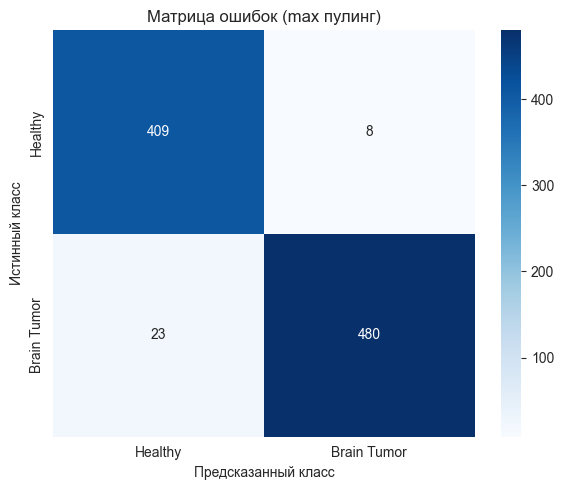

In [9]:
cm_max = confusion_matrix(y_test, binary_predictions_max)

print("\nМетрики классификации:")
print(classification_report(
    y_test,
    binary_predictions_max,
    target_names=['Healthy', 'Brain Tumor']
))

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_max,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Healthy", "Brain Tumor"],
    yticklabels=["Healthy", "Brain Tumor"],
    cbar=True
)

plt.title("Матрица ошибок (max пулинг)")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")

plt.tight_layout()
plt.show()

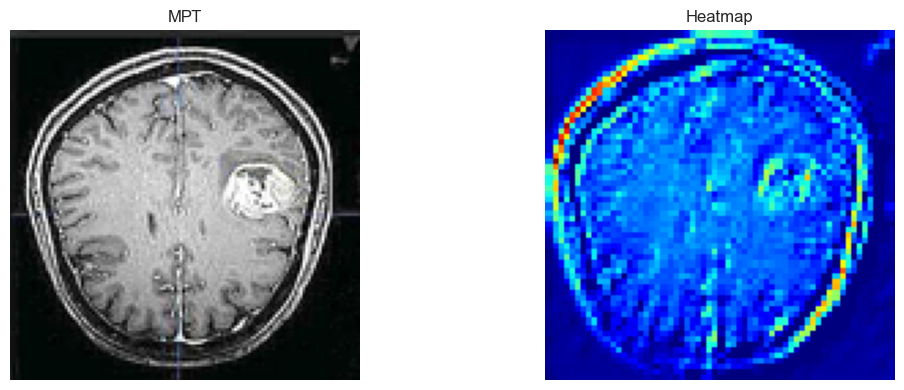

In [29]:
def get_earlier_conv_layer_name(model):
    conv_count = 0
    for layer in model.layers:
        if isinstance(layer, layers.Conv2D):
            conv_count += 1
            if conv_count == 2:
                return layer.name
    raise ValueError("Нет второго Conv2D")

last_conv_layer_name = get_earlier_conv_layer_name(model_max)
target_conv_layer = model_max.get_layer(last_conv_layer_name)

input_tensor = layers.Input(shape=(128, 128, 3))
x = input_tensor
for layer in model_max.layers:
    x = layer(x)
    if layer == target_conv_layer:
        conv_output = x

grad_model = Model(
    inputs=input_tensor,
    outputs=[conv_output, x]
)

def make_gradcam_heatmap(img_array, grad_model):
    with tf.GradientTape() as tape:
        conv_outputs, preds = grad_model(img_array)
        class_channel = preds[:, 0]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_output = conv_outputs[0]
    heatmap = conv_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-7)
    return heatmap.numpy()

def visualize_gradcam(img, heatmap):
    heatmap = np.maximum(heatmap, 0.0)
    heatmap = heatmap / (heatmap.max() + 1e-7)

    H_img, W_img = img.shape[0], img.shape[1]
    H_hm, W_hm = heatmap.shape

    heatmap_resized = cv2.resize(heatmap, (W_img, H_img), interpolation=cv2.INTER_NEAREST)
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)

    img_uint8 = np.uint8(255 * img)
    alpha = 0.4
    superimposed_img = (heatmap_colored * alpha + img_uint8 * (1 - alpha)).astype(np.uint8)
    superimposed_img = np.clip(superimposed_img, 0, 255)

    # ТОЛЬКО ГРАФИКИ
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(img, cmap="gray", vmin=0, vmax=1)
    plt.axis("off")
    plt.title("МРТ")

    plt.subplot(1, 2, 2)
    plt.imshow(heatmap_resized, cmap="jet", vmin=0, vmax=1)
    plt.axis("off")
    plt.title("Heatmap")

    plt.tight_layout()
    plt.show()

def load_and_preprocess_single_image(img_path):
    img = Image.open(img_path)
    img = img.convert("RGB")
    img = img.resize((128, 128))
    img_array = np.array(img)

    if img_array.dtype == np.uint16:
        img_array = img_array.astype(np.float32) / 65535.0
    else:
        img_array = img_array.astype(np.float32) / 255.0

    return img_array


img_path = "data/kagglehub_cache/datasets/preetviradiya/brian-tumor-dataset/versions/1/Brain Tumor Data Set/Brain Tumor Data Set/Brain Tumor/Cancer (1300).jpg"

img = load_and_preprocess_single_image(img_path)
img_array = np.expand_dims(img, axis=0)

heatmap = make_gradcam_heatmap(img_array, grad_model)
visualize_gradcam(img, heatmap)